# 📊 Voorspelling Jeugdpopulatie Almere (2019–2025)
## Gemeente Notebook
Dit notebook bevat het volledige CRISP-DM proces: van probleemdefinitie tot evaluatie.

## Business Understanding
**Probleem:**
Beschrijf hier het probleem van de gemeente Almere.

**Doel:**
Wat willen we voorspellen?

**Waarom is dit belangrijk?**
Koppel dit aan zorgcapaciteit en beleidsplanning.

In [2]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

# Ruwe CBS dataset inladen
df_cbs = pd.read_csv("../../data/raw/CBS_Kerncijfers.csv", sep=";")

print("Shape:", df_cbs.shape)
df_cbs.head()

ModuleNotFoundError: No module named 'seaborn'

## Data Preparation FASE 1


**Eerste verkenning (Wail + Faysal)**

In [ ]:
# Overzicht: kolommen, types, missende waarden
df_cbs.info()

# Beschrijvende statistiek (numeriek)
df_cbs.describe()
# Missende waarden overzicht (aantallen + percentages)
missing_counts = df_cbs.isnull().sum()
missing_pct = (missing_counts / len(df_cbs)) * 100

missing_overview = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_percentage": missing_pct
}).sort_values("missing_percentage", ascending=False)

missing_overview

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1536 entries, 0 to 1535
Columns: 411 entries, ID to GeweldsEnSeksueleMisdrijven_90
dtypes: float64(387), int64(13), object(11)
memory usage: 4.8+ MB


,missing_count,missing_percentage
HJVervoerInformatieEnCommunicatie_101,1536,100.0
GemiddeldeElektriciteitsleveringTotaal_53,1536,100.0
PersonenPerSoortUitkeringBijstand_89,1536,100.0
PersonenPerSoortUitkeringAO_90,1536,100.0
PersonenPerSoortUitkeringWW_91,1536,100.0
...,...,...
Gehuwd_14,0,0.0
Gescheiden_15,0,0.0
Verweduwd_16,0,0.0
Peildatum,0,0.0


**Filter op Almere en op wijken (Ismael)**

In [ ]:
# kolomnamen opschonen
df_cbs.columns = df_cbs.columns.astype(str).str.strip()

# gemeentenaam opschonen
df_cbs["Gemeentenaam_1"] = df_cbs["Gemeentenaam_1"].astype(str).str.strip()

# filter Almere
df_almere = df_cbs[df_cbs["Gemeentenaam_1"] == "Almere"].copy()
print("Shape Almere:", df_almere.shape)

# waardes opschonen + filter wijken
df_almere["SoortRegio_2"] = df_almere["SoortRegio_2"].astype(str).str.strip()
df_almere["Codering_3"] = df_almere["Codering_3"].astype(str).str.strip()

df_wijk = df_almere[df_almere["SoortRegio_2"] == "Wijk"].copy()
df_wijk = df_wijk[df_wijk["Codering_3"].str.startswith("WK")].copy()

print("Shape wijken:", df_wijk.shape)
df_wijk.head()

Shape Almere: (1536, 411)
Shape wijken: (308, 411)


,ID,Peildatum,WijkenEnBuurten,Gemeentenaam_1,SoortRegio_2,Codering_3,IndelingswijzigingGemeenteWijkBuurt_4,AantalInwoners_5,Mannen_6,Vrouwen_7,...,PersonenPerSoortUitkeringAO_81,PersonenPerSoortUitkeringWW_82,PersonenPerSoortUitkeringAOW_83,JongerenMetJeugdzorgInNatura_84,PercentageJongerenMetJeugdzorg_85,WmoClienten_86,WmoClientenRelatief_87,TotaalDiefstalUitWoningSchuurED_88,VernielingMisdrijfTegenOpenbareOrde_89,GeweldsEnSeksueleMisdrijven_90
1,385,1-1-2025,WK003401,Almere,Wijk,WK003401,1.0,1810,880,930,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,388,1-1-2025,WK003402,Almere,Wijk,WK003402,1.0,2890,1395,1500,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10,394,1-1-2025,WK003403,Almere,Wijk,WK003403,1.0,2500,1205,1300,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15,399,1-1-2025,WK003404,Almere,Wijk,WK003404,1.0,2220,1065,1155,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19,403,1-1-2025,WK003405,Almere,Wijk,WK003405,1.0,2365,1130,1235,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Basis datakwaliteit checks (Wail + Noah + Ismael)**

In [ ]:
# Dubbele combinaties wijkcode + peildatum
dup_count = df_wijk.duplicated(subset=["Codering_3", "Peildatum"]).sum()
print("Duplicaten (Codering_3 + Peildatum):", dup_count)

# Volledig dubbele rijen
full_dup = df_wijk.duplicated().sum()
print("Volledig dubbele rijen:", full_dup)

# Unieke wijken
print("Aantal unieke wijken:", df_wijk["Codering_3"].nunique())

# Aantal jaren per wijk
jaren_per_wijk = df_wijk.groupby("Codering_3")["Peildatum"].nunique()
jaren_per_wijk.describe()

# Missende jaren per wijk
alle_jaren = sorted(df_wijk["Peildatum"].dropna().unique())

print("Missende jaren per wijk (alleen wijken met missende jaren):")
for wijk, groep in df_wijk.groupby("Codering_3"):
    aanwezige = sorted(groep["Peildatum"].dropna().unique())
    missend = sorted(set(alle_jaren) - set(aanwezige))
    if missend:
        print(f"{wijk} mist: {missend}")

Duplicaten (Codering_3 + Peildatum): 0
Volledig dubbele rijen: 0
Aantal unieke wijken: 71
Missende jaren per wijk (alleen wijken met missende jaren):
WK003407 mist: ['1-1-2018', '1-1-2019', '1-1-2020', '1-1-2021']
WK003408 mist: ['1-1-2018', '1-1-2019', '1-1-2020', '1-1-2021']
WK003409 mist: ['1-1-2018', '1-1-2019', '1-1-2020', '1-1-2021']
WK003410 mist: ['1-1-2018', '1-1-2019', '1-1-2020', '1-1-2021']
WK003411 mist: ['1-1-2018', '1-1-2019', '1-1-2020', '1-1-2021']
WK003414 mist: ['1-1-2018', '1-1-2019', '1-1-2020', '1-1-2021']
WK003415 mist: ['1-1-2018', '1-1-2019', '1-1-2020', '1-1-2021']
WK003416 mist: ['1-1-2018', '1-1-2019', '1-1-2020', '1-1-2021']
WK003417 mist: ['1-1-2018', '1-1-2019', '1-1-2020', '1-1-2021']
WK003418 mist: ['1-1-2018', '1-1-2019', '1-1-2020', '1-1-2021']
WK003419 mist: ['1-1-2018', '1-1-2019', '1-1-2020', '1-1-2021']
WK003420 mist: ['1-1-2018', '1-1-2019', '1-1-2020', '1-1-2021']
WK003421 mist: ['1-1-2018', '1-1-2019', '1-1-2020', '1-1-2021']
WK003422 mist: ['1

**Kernvariabelen opschonen (Bo + Faysal)**

In [ ]:
cols_check = ["AantalInwoners_5", "k_0Tot15Jaar_8", "k_15Tot25Jaar_9"]

# naar numeriek
for col in cols_check:
    df_wijk[col] = pd.to_numeric(df_wijk[col], errors="coerce")

# NaN eruit
df_wijk = df_wijk.dropna(subset=cols_check)

# 0-waarden eruit
for col in cols_check:
    df_wijk = df_wijk[df_wijk[col] != 0]

print("Shape na opschonen kernvariabelen:", df_wijk.shape)
df_wijk[cols_check].describe()

# Extra logische checks (Faysel)
kol_totaal = "AantalInwoners_5"
kol_0_15 = "k_0Tot15Jaar_8"
kol_15_25 = "k_15Tot25Jaar_9"

checks = {
    "negatief_0_15": (df_wijk[kol_0_15] < 0).sum(),
    "negatief_15_25": (df_wijk[kol_15_25] < 0).sum(),
    "negatief_totaal": (df_wijk[kol_totaal] < 0).sum(),
    "0_15_groter_dan_totaal": (df_wijk[kol_0_15] > df_wijk[kol_totaal]).sum(),
    "15_25_groter_dan_totaal": (df_wijk[kol_15_25] > df_wijk[kol_totaal]).sum(),
}
checks

Shape na opschonen kernvariabelen: (237, 411)


{'negatief_0_15': np.int64(0),
 'negatief_15_25': np.int64(0),
 'negatief_totaal': np.int64(0),
 '0_15_groter_dan_totaal': np.int64(0),
 '15_25_groter_dan_totaal': np.int64(0)}

**Kolommen duidelijk maken + tijdstructuur (Ismael + Mo + Wail)**

In [ ]:
# Kolommen hernoemen naar duidelijke namen
df_wijk = df_wijk.rename(columns={
    "WijkenEnBuurten": "Wijk",
    "Codering_3": "WijkCode",
    "AantalInwoners_5": "AantalInwoners",
    "k_0Tot15Jaar_8": "Aantal_0_15",
    "k_15Tot25Jaar_9": "Aantal_15_25",
})

# Peildatum omzetten naar datetime + Jaar maken
df_wijk["Peildatum"] = pd.to_datetime(df_wijk["Peildatum"], errors="coerce")
df_wijk["Jaar"] = df_wijk["Peildatum"].dt.year

# erwijder rijen zonder geldige datum/jaar
df_wijk = df_wijk.dropna(subset=["Peildatum", "Jaar"]).copy()
df_wijk["Jaar"] = df_wijk["Jaar"].astype(int)

# sorteren (handig voor tijdreeksen)
df_wijk = df_wijk.sort_values(["WijkCode", "Jaar"]).reset_index(drop=True)

# Duplicaten check (wijkcode + jaar)
dup_wijk_jaar = df_wijk.duplicated(subset=["WijkCode", "Jaar"]).sum()
print("Duplicaten (WijkCode + Jaar):", dup_wijk_jaar)

# Kolommen selecteren (Wail)
keep_cols = [
    "Peildatum", "Jaar", "WijkCode", "Wijk",
    "AantalInwoners", "Aantal_0_15", "Aantal_15_25"
]

missing = [c for c in keep_cols if c not in df_wijk.columns]
if missing:
    print("Ontbrekende kolommen:", missing)

df_wijk = df_wijk[[c for c in keep_cols if c in df_wijk.columns]].copy()

print("Kolommen na selectie:", df_wijk.columns.tolist())
print("Shape na selectie:", df_wijk.shape)

df_wijk.head()

Duplicaten (WijkCode + Jaar): 0
Kolommen na selectie: ['Peildatum', 'Jaar', 'WijkCode', 'Wijk', 'AantalInwoners', 'Aantal_0_15', 'Aantal_15_25']
Shape na selectie: (237, 7)


,Peildatum,Jaar,WijkCode,Wijk,AantalInwoners,Aantal_0_15,Aantal_15_25
0,2018-01-01,2018,WK003401,WK003401,22790,3975,2420
1,2019-01-01,2019,WK003401,WK003401,22875,3945,2415
2,2020-01-01,2020,WK003401,WK003401,23275,4005,2485
3,2021-01-01,2021,WK003401,WK003401,23530,4180,2465
4,2022-01-01,2022,WK003401,WK003401,1635,175,150


**Percentages toevoegen (Faysel) – handig voor latere analyse**

In [ ]:
df_wijk["pct_0_15"] = (df_wijk["Aantal_0_15"] / df_wijk["AantalInwoners"]) * 100
df_wijk["pct_15_25"] = (df_wijk["Aantal_15_25"] / df_wijk["AantalInwoners"]) * 100

df_wijk[["pct_0_15", "pct_15_25"]].describe()

,pct_0_15,pct_15_25
count,237.000000,237.000000
mean,18.277507,12.805460
std,6.034239,6.198061
min,2.083333,6.250000
25%,15.671642,10.135135
50%,17.287234,11.790393
75%,19.288646,14.258735
max,57.142857,83.333333


**Export: dataset klaar voor analyse**

In [ ]:
output_path = Path("../../data/processed_Gezamenlijke/df_fase1_ready_for_analysis.csv")
df_wijk.to_csv(output_path, index=False)

output_path.as_posix()

'../../data/processed_Gezamenlijke/df_fase1_ready_for_analysis.csv'

##  Data Understanding FASE 2

In [ ]:
df = pd.read_csv("../../data/processed_Gezamenlijke/df_fase1_ready_for_analysis.csv")
print("Shape:", df.shape)
df.head()


Shape: (237, 9)


,Peildatum,Jaar,WijkCode,Wijk,AantalInwoners,Aantal_0_15,Aantal_15_25,pct_0_15,pct_15_25
0,2018-01-01,2018,WK003401,WK003401,22790,3975,2420,17.441860,10.618692
1,2019-01-01,2019,WK003401,WK003401,22875,3945,2415,17.245902,10.557377
2,2020-01-01,2020,WK003401,WK003401,23275,4005,2485,17.207304,10.676692
3,2021-01-01,2021,WK003401,WK003401,23530,4180,2465,17.764556,10.475988
4,2022-01-01,2022,WK003401,WK003401,1635,175,150,10.703364,9.174312


**Tijdreeks voorbereiden (Mo + Ismael)**

In [ ]:
df["Peildatum"] = pd.to_datetime(df["Peildatum"], errors="coerce")
df["Jaar"] = df["Peildatum"].dt.year

df = df.sort_values(["Wijk", "Jaar"]).reset_index(drop=True)

df[["Wijk","Jaar"]].head()

,Wijk,Jaar
0,WK003401,2018
1,WK003401,2019
2,WK003401,2020
3,WK003401,2021
4,WK003401,2022


**Scatterplot relatie inwoners vs jongeren (Mo + Faysel)**

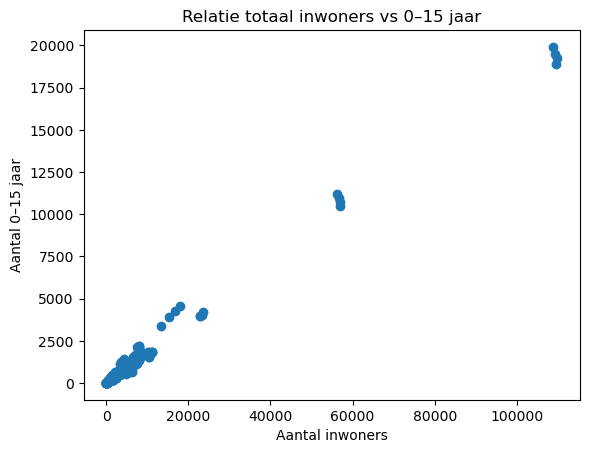

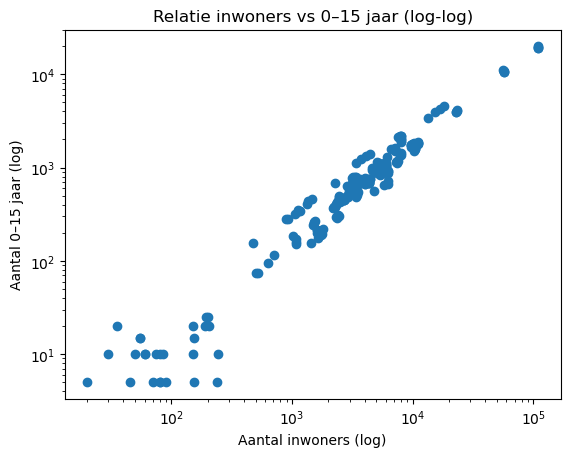

In [ ]:
plt.scatter(df["AantalInwoners"], df["Aantal_0_15"])
plt.xlabel("Aantal inwoners")
plt.ylabel("Aantal 0–15 jaar")
plt.title("Relatie totaal inwoners vs 0–15 jaar")
plt.show()


plt.scatter(df["AantalInwoners"], df["Aantal_0_15"])
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Aantal inwoners (log)")
plt.ylabel("Aantal 0–15 jaar (log)")
plt.title("Relatie inwoners vs 0–15 jaar (log-log)")
plt.show()

**Trend van jongeren door de jaren (Mo)**

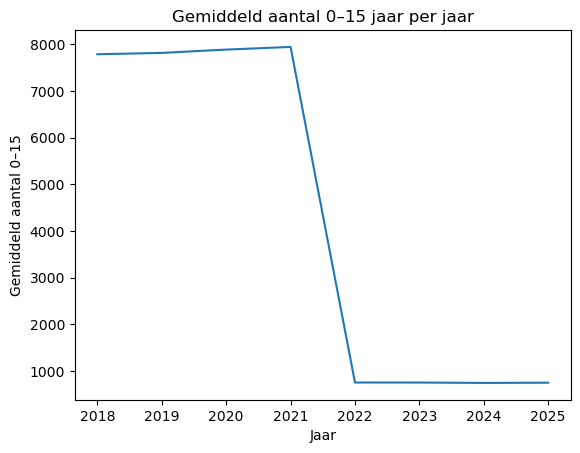

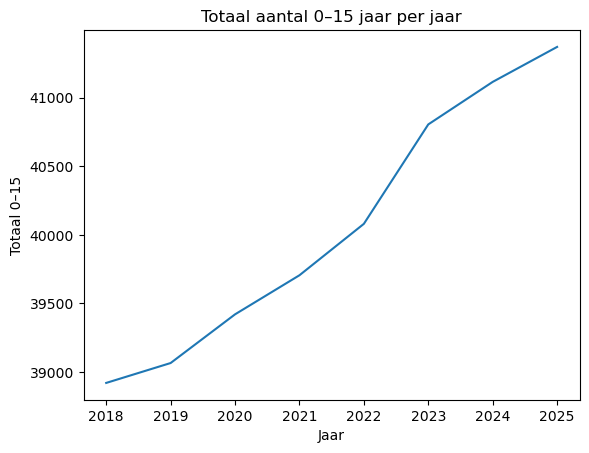

In [ ]:
df.groupby("Jaar")["Aantal_0_15"].mean().plot()
plt.title("Gemiddeld aantal 0–15 jaar per jaar")
plt.xlabel("Jaar")
plt.ylabel("Gemiddeld aantal 0–15")
plt.show()


df.groupby("Jaar")["Aantal_0_15"].sum().plot()
plt.title("Totaal aantal 0–15 jaar per jaar")
plt.xlabel("Jaar")
plt.ylabel("Totaal 0–15")
plt.show()

**Vergelijking tussen wijken (Faysel)**

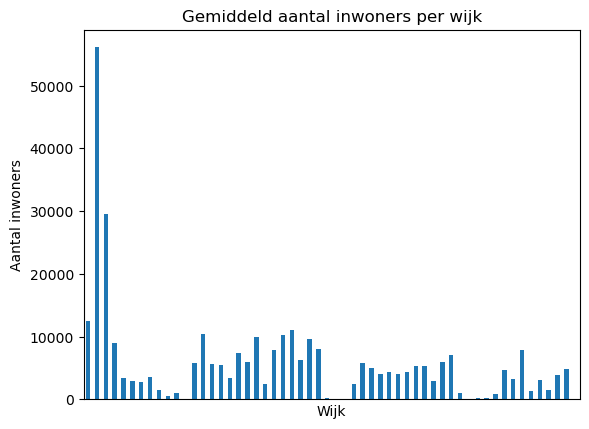

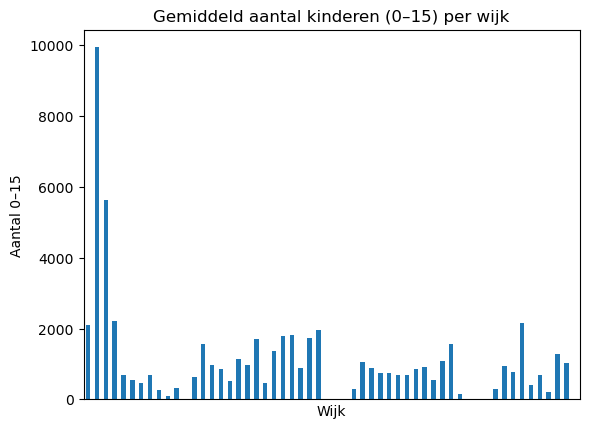

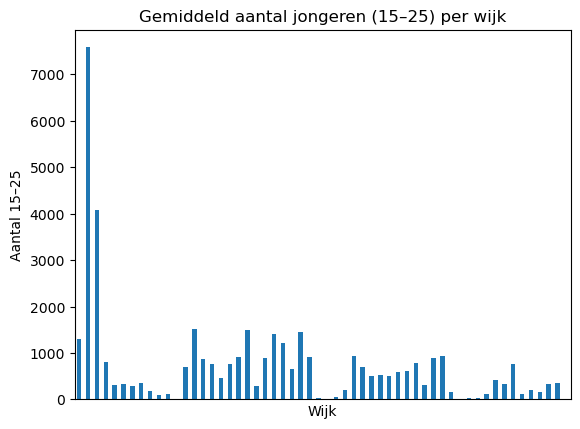

In [ ]:
df.groupby("Wijk")["AantalInwoners"].mean().plot(kind="bar")
plt.title("Gemiddeld aantal inwoners per wijk")
plt.ylabel("Aantal inwoners")
plt.xticks([])
plt.show()

df.groupby("Wijk")["Aantal_0_15"].mean().plot(kind="bar")
plt.title("Gemiddeld aantal kinderen (0–15) per wijk")
plt.ylabel("Aantal 0–15")
plt.xticks([])
plt.show()

df.groupby("Wijk")["Aantal_15_25"].mean().plot(kind="bar")
plt.title("Gemiddeld aantal jongeren (15–25) per wijk")
plt.ylabel("Aantal 15–25")
plt.xticks([])
plt.show()

**Correlaties tussen variabelen (Faysal)**

In [ ]:
df[["AantalInwoners", "Aantal_0_15", "Aantal_15_25"]].corr()

,AantalInwoners,Aantal_0_15,Aantal_15_25
AantalInwoners,1.000000,0.995671,0.996897
Aantal_0_15,0.995671,1.000000,0.989825
Aantal_15_25,0.996897,0.989825,1.000000


**Percentage jeugd berekenen (Ismael + Wail)**

In [ ]:
df["pct_0_15"] = (df["Aantal_0_15"] / df["AantalInwoners"]) * 100
df["pct_15_25"] = (df["Aantal_15_25"] / df["AantalInwoners"]) * 100
df["Perc_TotaleJeugd"] = df["pct_0_15"] + df["pct_15_25"]

df[["pct_0_15", "pct_15_25", "Perc_TotaleJeugd"]].describe()

# Onmogelijke waarden (>100%)
df[df["Perc_TotaleJeugd"] > 100][
    ["Wijk", "WijkCode", "AantalInwoners", "Aantal_0_15", "Aantal_15_25", "Perc_TotaleJeugd"]
].head(10)

# Extra check: jeugd groter dan totaal (moet 0 zijn)
df[(df["Aantal_0_15"] + df["Aantal_15_25"]) > df["AantalInwoners"]].head(10)

# Filter onmogelijke rijen weg
df = df[df["Perc_TotaleJeugd"] <= 100].copy()

**Top 10 wijken met hoogste jeugdpercentage (Wail)**


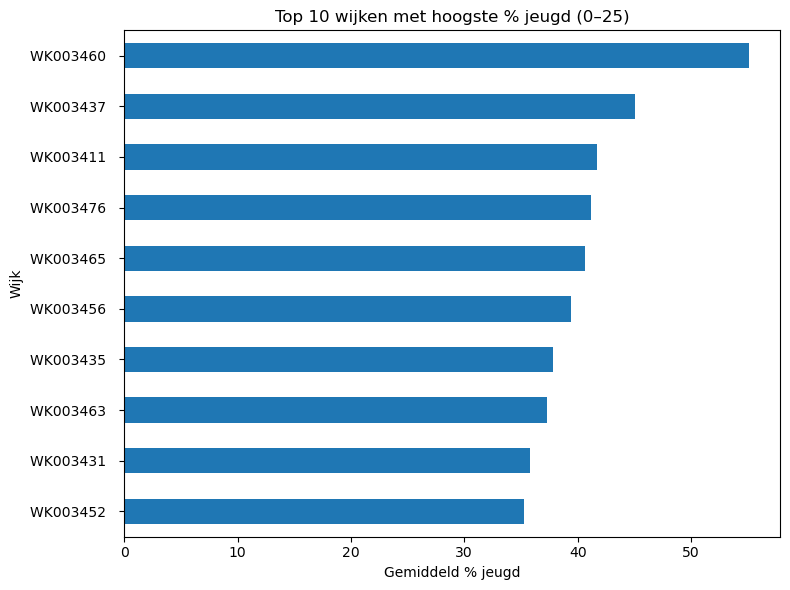

In [ ]:
gemiddeld_wijk = df.groupby("Wijk")["Perc_TotaleJeugd"].mean()
top10_wijk = gemiddeld_wijk.sort_values(ascending=False).head(10)

plt.figure(figsize=(8,6))
top10_wijk.sort_values().plot(kind="barh")
plt.title("Top 10 wijken met hoogste % jeugd (0–25)")
plt.xlabel("Gemiddeld % jeugd")
plt.tight_layout()
plt.show()

**Tijdreeks per wijk (Bo + Ismael)**

In [ ]:
# Totale jeugd berekenen
df["Totale_Jeugd"] = df["Aantal_0_15"] + df["Aantal_15_25"]

# Top 10 wijken bepalen
top10_wijken = (
    df.groupby("Wijk")["Totale_Jeugd"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .index
)

print("Top 10 wijken:", list(top10_wijken))

Top 10 wijken: ['WK003402  ', 'WK003403  ', 'WK003401  ', 'WK003427  ', 'WK003424  ', 'WK003430  ', 'WK003418  ', 'WK003428  ', 'WK003404  ', 'WK003463  ']


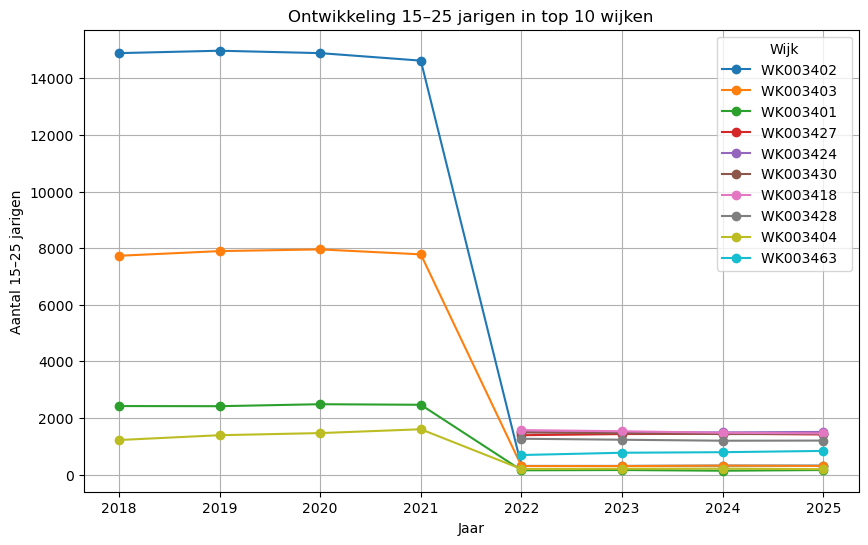

In [ ]:
plt.figure(figsize=(10,6))

for wijk in top10_wijken:
    
    subset = df[df["Wijk"] == wijk].sort_values("Jaar")

    plt.plot(
        subset["Jaar"],
        subset["Aantal_15_25"],
        marker="o",
        label=wijk
    )

plt.xlabel("Jaar")
plt.ylabel("Aantal 15–25 jarigen")
plt.title("Ontwikkeling 15–25 jarigen in top 10 wijken")

plt.legend(title="Wijk")
plt.grid(True)

plt.show()

**Bo’s stadsdeel mapping (alleen als WijkCode WK003401 etc.)**

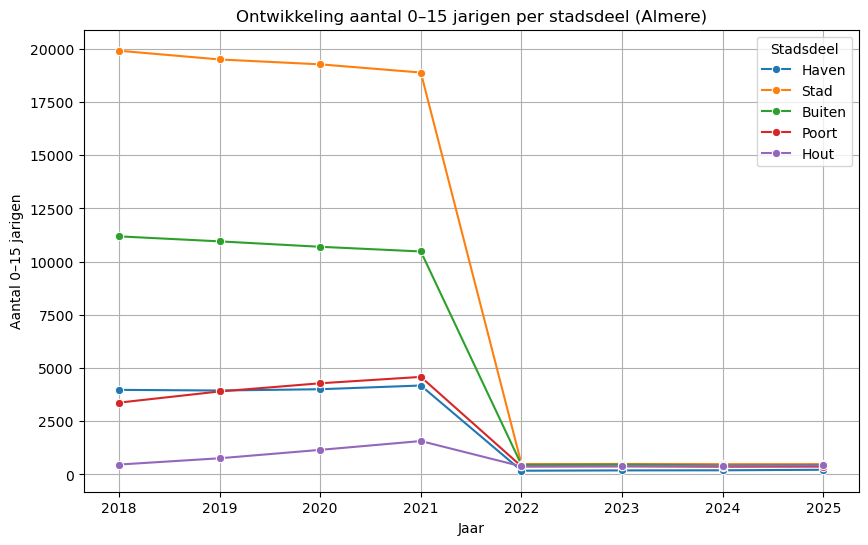

In [ ]:
# Mapping wijkcodes -> stadsdelen
wijk_mapping = {
    "WK003401": "Haven",
    "WK003402": "Stad",
    "WK003403": "Buiten",
    "WK003404": "Poort",
    "WK003405": "Hout",
}

df["Stadsdeel"] = df["WijkCode"].map(wijk_mapping)

df_map = df.dropna(subset=["Stadsdeel"]).copy()

plt.figure(figsize=(10,6))

sns.lineplot(
    data=df_map,
    x="Jaar",
    y="Aantal_0_15",
    hue="Stadsdeel",
    marker="o"
)

plt.title("Ontwikkeling aantal 0–15 jarigen per stadsdeel (Almere)")
plt.xlabel("Jaar")
plt.ylabel("Aantal 0–15 jarigen")

plt.grid(True)

plt.legend(title="Stadsdeel")

plt.show()

# Fase 3 – Data Preparation

In deze fase wordt de dataset voorbereid voor modellering. De analyseklare dataset uit fase 2 wordt uitgebreid met nieuwe features die gebruikt kunnen worden in het regressiemodel.

De input van deze fase is:

`../../data/processed/df_v8_ready_for_analysis.csv`

Het doel is om de dataset model-klaar te maken. Binnen deze fase zijn door verschillende teamleden aanvullende features en controles uitgevoerd. Deze onderdelen worden hieronder stap voor stap samengebracht.

De uiteindelijke output van deze fase is:

`../../data/processed/df_v12_model_ready.csv`

## 3.1 Basisdataset laden

We starten vanuit de analyseklare dataset uit fase 2. Deze dataset bevat per wijk en per jaar de belangrijkste demografische variabelen die als basis dienen voor verdere feature engineering.

In [3]:
import pandas as pd
from pathlib import Path

base_path = Path("../../data/processed/df_v8_ready_for_analysis.csv")
df_base = pd.read_csv(base_path)

df_base.head()

,Peildatum,Wijk,AantalInwoners_5,k_0Tot15Jaar_8,k_15Tot25Jaar_9,Jaar,pct_0_15,pct_15_25
0,2018-01-01,WK003401,22790,3975,2420,2018,17.441860,10.618692
1,2019-01-01,WK003401,22875,3945,2415,2019,17.245902,10.557377
2,2020-01-01,WK003401,23275,4005,2485,2020,17.207304,10.676692
3,2021-01-01,WK003401,23530,4180,2465,2021,17.764556,10.475988
4,2022-01-01,WK003401,1635,175,150,2022,10.703364,9.174312


In [4]:
df_base[["Wijk", "Jaar"]].head()

,Wijk,Jaar
0,WK003401,2018
1,WK003401,2019
2,WK003401,2020
3,WK003401,2021
4,WK003401,2022


In [5]:
df_base.duplicated(subset=["Wijk", "Jaar"]).sum()

np.int64(0)

De controle op `Wijk` + `Jaar` laat zien of iedere combinatie uniek voorkomt. Dit is belangrijk, omdat de verschillende feature-datasets later op deze sleutel worden samengevoegd.

## 3.2 Ratio jongeren ten opzichte van totale bevolking (Ismael)

In deze stap worden relatieve indicatoren berekend om wijken eerlijker met elkaar te kunnen vergelijken. Absolute aantallen jongeren kunnen stijgen doordat de totale bevolking groeit, maar zeggen minder over de werkelijke demografische samenstelling. Daarom wordt het aantal jongeren gedeeld door het totaal aantal inwoners.

In [6]:
df = pd.read_csv("../../data/processed/df_v8_ready_for_analysis.csv")
df.columns = df.columns.astype(str).str.strip()

# Peildatum -> Jaar
df["Peildatum"] = pd.to_datetime(df["Peildatum"], dayfirst=True, errors="coerce")
df["Jaar"] = df["Peildatum"].dt.year

# Alleen consistente jaren
df = df[df["Jaar"] <= 2021].copy()

# wijkcodes opschonen
df["Wijk"] = df["Wijk"].astype(str).str.strip()

# Ratio's
df["Ratio_0_15"] = df["k_0Tot15Jaar_8"] / df["AantalInwoners_5"]
df["Ratio_15_25"] = df["k_15Tot25Jaar_9"] / df["AantalInwoners_5"]

# Checks
print("Min/Max Ratio 0–15:", df["Ratio_0_15"].min(), df["Ratio_0_15"].max())
print("Min/Max Ratio 15–25:", df["Ratio_15_25"].min(), df["Ratio_15_25"].max())

Min/Max Ratio 0–15: 0.17207303974221266 0.25566825775656327
Min/Max Ratio 15–25: 0.08333333333333333 0.13963489555906616


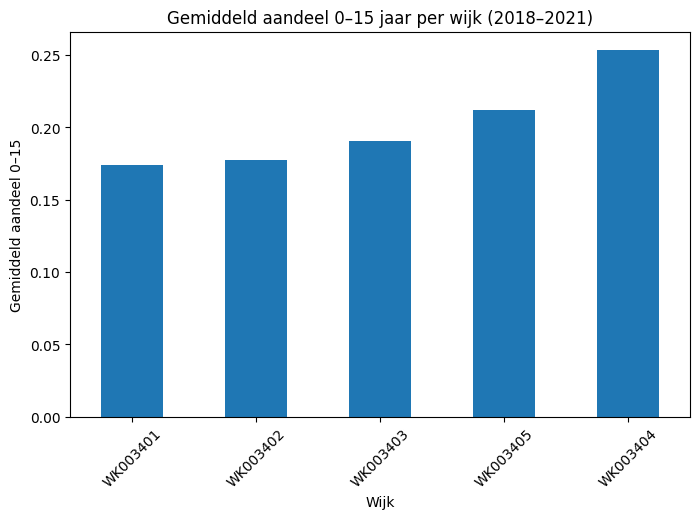

In [7]:
gemiddeld_0 = df.groupby("Wijk")["Ratio_0_15"].mean().sort_values()

plt.figure(figsize=(8,5))
gemiddeld_0.plot(kind="bar")

plt.ylabel("Gemiddeld aandeel 0–15")
plt.title("Gemiddeld aandeel 0–15 jaar per wijk (2018–2021)")
plt.xticks(rotation=45)
plt.show()

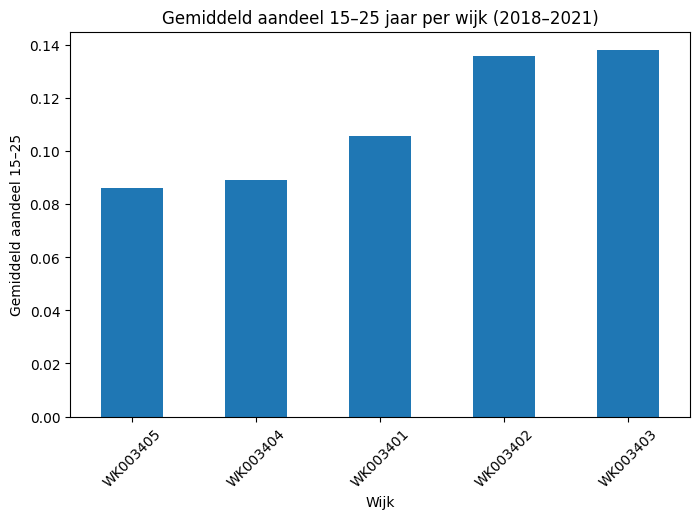

In [8]:
gemiddeld_1 = df.groupby("Wijk")["Ratio_15_25"].mean().sort_values()

plt.figure(figsize=(8,5))
gemiddeld_1.plot(kind="bar")

plt.ylabel("Gemiddeld aandeel 15–25")
plt.title("Gemiddeld aandeel 15–25 jaar per wijk (2018–2021)")
plt.xticks(rotation=45)
plt.show()

In [9]:
df.to_csv("../../data/processed/df_v10_ratio_temp.csv", index=False)

De ratio-features laten het aandeel jongeren binnen de totale bevolking zien. Daarmee kunnen verschillen tussen wijken beter worden geïnterpreteerd dan met alleen absolute aantallen.

## 3.3 Stabiliteit en plausibiliteit van ratio-features controleren (Ismael)

Na het berekenen van de ratio’s wordt gecontroleerd of deze nieuwe variabelen technisch correct en inhoudelijk plausibel zijn. Hierbij wordt gekeken naar onmogelijke waarden, null-waarden en deling door nul.

In [10]:
df = pd.read_csv("../../data/processed/df_v10_ratio_temp.csv")
df.columns = df.columns.astype(str).str.strip()

print("Start aantal rijen:", len(df))

print("\nControle ratio > 1:")
print("Ratio_0_15 > 1:", (df["Ratio_0_15"] > 1).sum())
print("Ratio_15_25 > 1:", (df["Ratio_15_25"] > 1).sum())

print("\nControle ratio < 0:")
print("Ratio_0_15 < 0:", (df["Ratio_0_15"] < 0).sum())
print("Ratio_15_25 < 0:", (df["Ratio_15_25"] < 0).sum())

print("\nAantal NaN waarden:")
print(df[["Ratio_0_15", "Ratio_15_25"]].isna().sum())

print("\nAantal rijen met inwoners = 0:")
print((df["AantalInwoners_5"] == 0).sum())

Start aantal rijen: 20

Controle ratio > 1:
Ratio_0_15 > 1: 0
Ratio_15_25 > 1: 0

Controle ratio < 0:
Ratio_0_15 < 0: 0
Ratio_15_25 < 0: 0

Aantal NaN waarden:
Ratio_0_15     0
Ratio_15_25    0
dtype: int64

Aantal rijen met inwoners = 0:
0


In [11]:
df_clean = df[
    (df["AantalInwoners_5"] > 0) &
    (df["Ratio_0_15"].between(0,1)) &
    (df["Ratio_15_25"].between(0,1))
].copy()

print("\nAantal rijen na cleaning:", len(df_clean))


Aantal rijen na cleaning: 20


Uit deze controle blijkt of de berekende ratio-features bruikbaar zijn voor verdere analyse en modellering.

## 3.4 Lag-feature maken op basis van vorige waarde (Wail)

In deze stap wordt een lag-feature gemaakt. Een lag-feature gebruikt een waarde van het vorige jaar als voorspeller voor het huidige jaar. Dit kan helpen om trends in de data beter te modelleren.

In [12]:
import pandas as pd

input_path = "../../data/processed/df_v8_ready_for_analysis.csv"
df = pd.read_csv(input_path)

print(df.shape)
df.head()

(237, 8)


,Peildatum,Wijk,AantalInwoners_5,k_0Tot15Jaar_8,k_15Tot25Jaar_9,Jaar,pct_0_15,pct_15_25
0,2018-01-01,WK003401,22790,3975,2420,2018,17.441860,10.618692
1,2019-01-01,WK003401,22875,3945,2415,2019,17.245902,10.557377
2,2020-01-01,WK003401,23275,4005,2485,2020,17.207304,10.676692
3,2021-01-01,WK003401,23530,4180,2465,2021,17.764556,10.475988
4,2022-01-01,WK003401,1635,175,150,2022,10.703364,9.174312


In [13]:
df = df.sort_values(["Wijk", "Jaar"])

df["Jeugdzorg"] = df["k_0Tot15Jaar_8"] + df["k_15Tot25Jaar_9"]

df["Jeugdzorg_lag1"] = df.groupby("Wijk")["Jeugdzorg"].shift(1)

df.head()

,Peildatum,Wijk,AantalInwoners_5,k_0Tot15Jaar_8,k_15Tot25Jaar_9,Jaar,pct_0_15,pct_15_25,Jeugdzorg,Jeugdzorg_lag1
0,2018-01-01,WK003401,22790,3975,2420,2018,17.441860,10.618692,6395,NaN
1,2019-01-01,WK003401,22875,3945,2415,2019,17.245902,10.557377,6360,6395.0
2,2020-01-01,WK003401,23275,4005,2485,2020,17.207304,10.676692,6490,6360.0
3,2021-01-01,WK003401,23530,4180,2465,2021,17.764556,10.475988,6645,6490.0
4,2022-01-01,WK003401,1635,175,150,2022,10.703364,9.174312,325,6645.0


In [14]:
df = df.dropna(subset=["Jeugdzorg_lag1"])

print(df.shape)

(181, 10)


In [15]:
output_path = "../../data/processed/df_v12_model_ready.csv"
df.to_csv(output_path, index=False)

print("Dataset opgeslagen:", output_path)

Dataset opgeslagen: ../../data/processed/df_v12_model_ready.csv


Met `groupby("Wijk")` wordt de lag alleen binnen dezelfde wijk berekend. De functie `shift(1)` verschuift de waarden één jaar naar beneden, zodat de waarde van het vorige jaar beschikbaar wordt als nieuwe variabele.

## 3.5 Groei van leeftijdsgroepen per wijk analyseren (Bo)

In dit onderdeel wordt gekeken naar de ontwikkeling van de leeftijdsgroepen 0–15 jaar en 15–25 jaar tussen 2018 en 2021. De groei wordt zowel absoluut als procentueel weergegeven.

In [16]:
df_groei = pd.read_csv('../../data/processed/df_v10_ratio_temp.csv')
wijk_mapping = {
    "WK003401": "Haven",
    "WK003402": "Stad",
    "WK003403": "Buiten",
    "WK003404": "Poort",
    "WK003405": "Hout",
}

df_groei["Stadsdeel"] = df_groei["Wijk"].map(wijk_mapping)

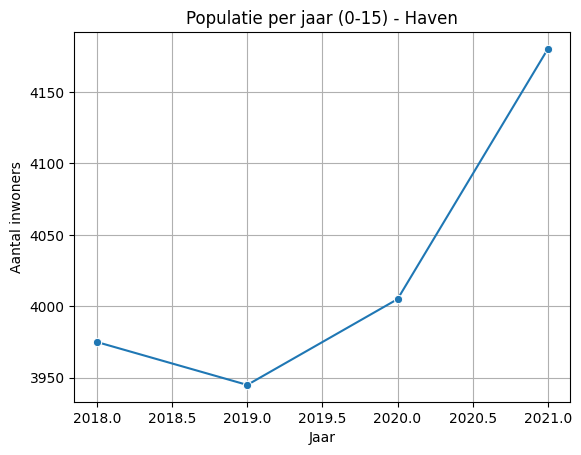

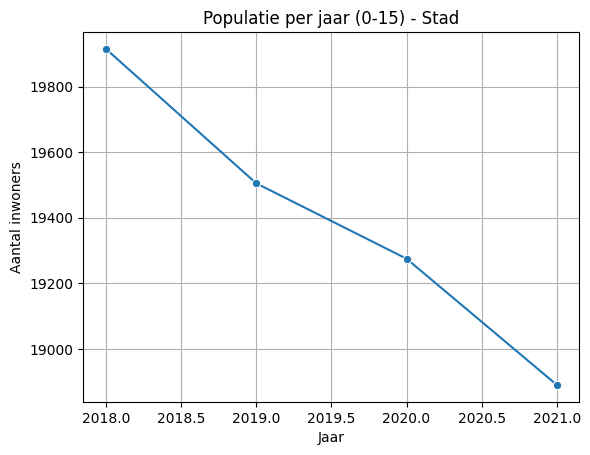

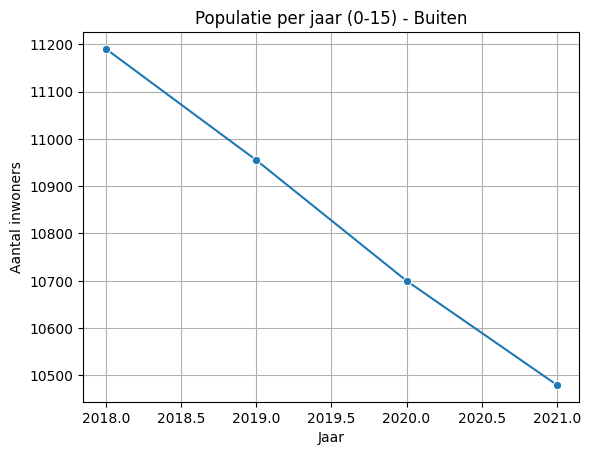

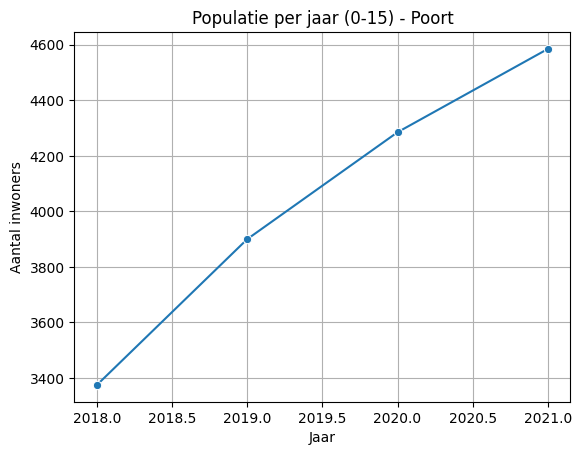

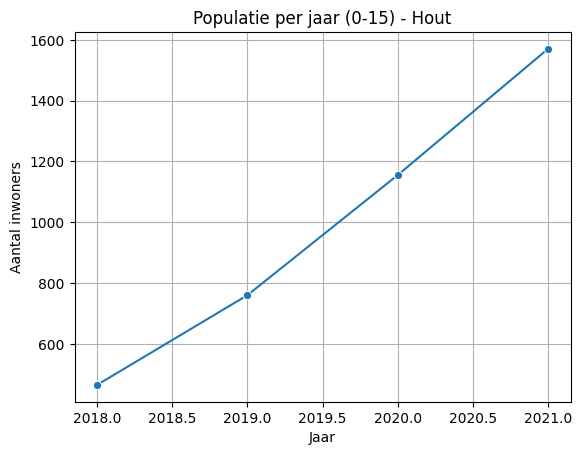

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

for wijk in df_groei["Stadsdeel"].unique():
    plt.figure()
    
    subset1 = df_groei[df_groei["Stadsdeel"] == wijk]
    
    ax = sns.lineplot(
        data=subset1,
        x="Jaar",
        y="k_0Tot15Jaar_8",
        marker="o"
    )
    
    ax.grid(True)
    plt.title(f"Populatie per jaar (0-15) - {wijk}")
    plt.xlabel("Jaar")
    plt.ylabel("Aantal inwoners")
    plt.show()

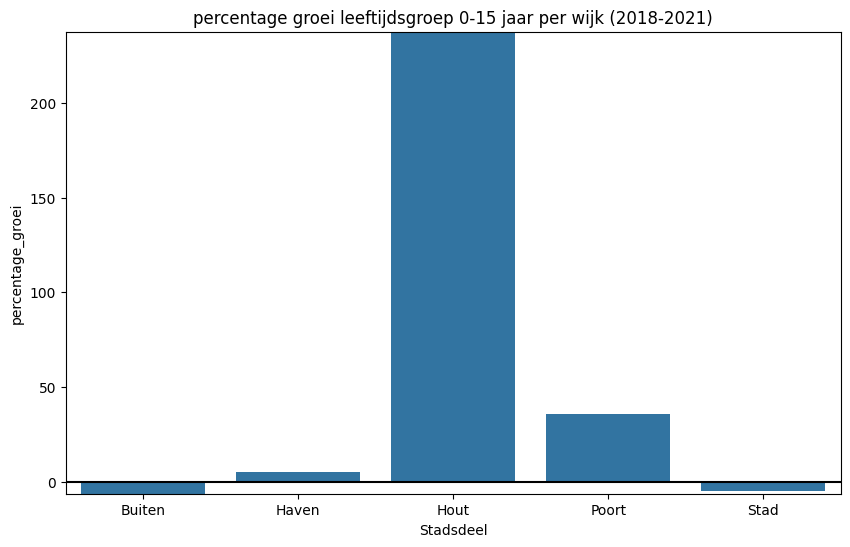

In [19]:
subset2 = df_groei

subset2['Peildatum'] = pd.to_datetime(subset2['Peildatum'])

subset2 = subset2[subset2['Jaar'].isin([2018, 2021])]

subset2 = subset2.pivot(index='Stadsdeel', columns='Jaar', values='k_0Tot15Jaar_8')

subset2["groei"] = subset2[2021] - subset2[2018]

subset2["percentage_groei"] = (subset2["groei"] / subset2[2018]) * 100
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=subset2.reset_index(),
    x='Stadsdeel',
    y='percentage_groei',
)

plt.title('percentage groei leeftijdsgroep 0-15 jaar per wijk (2018-2021)')

ax.axhline(0, color='black')
ax.set_ylim(subset2['percentage_groei'].min(), subset2['percentage_groei'].max())
plt.show()

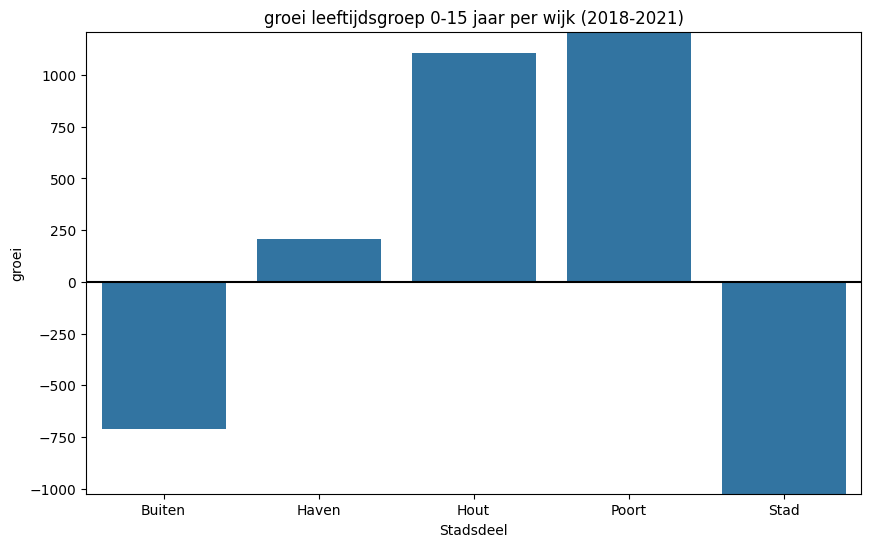

In [20]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=subset2.reset_index(),
    x='Stadsdeel',
    y='groei',
)

plt.title('groei leeftijdsgroep 0-15 jaar per wijk (2018-2021)')

ax.axhline(0, color='black')
ax.set_ylim(subset2['groei'].min(), subset2['groei'].max())
plt.show()

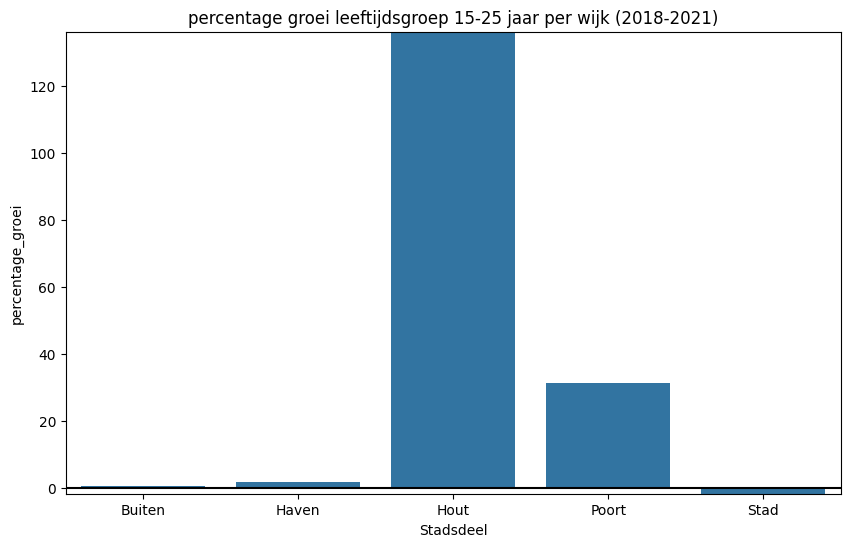

In [21]:
subset3 = df_groei

subset3['Peildatum'] = pd.to_datetime(subset3['Peildatum'])

subset3 = subset3[subset3['Jaar'].isin([2018, 2021])]

subset3 = subset3.pivot(index='Stadsdeel', columns='Jaar', values='k_15Tot25Jaar_9')

subset3["groei"] = subset3[2021] - subset3[2018]

subset3["percentage_groei"] = (subset3["groei"] / subset3[2018]) * 100
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=subset3.reset_index(),
    x='Stadsdeel',
    y='percentage_groei',
)

plt.title('percentage groei leeftijdsgroep 15-25 jaar per wijk (2018-2021)')

ax.axhline(0, color='black')
ax.set_ylim(subset3['percentage_groei'].min(), subset3['percentage_groei'].max())
plt.show()

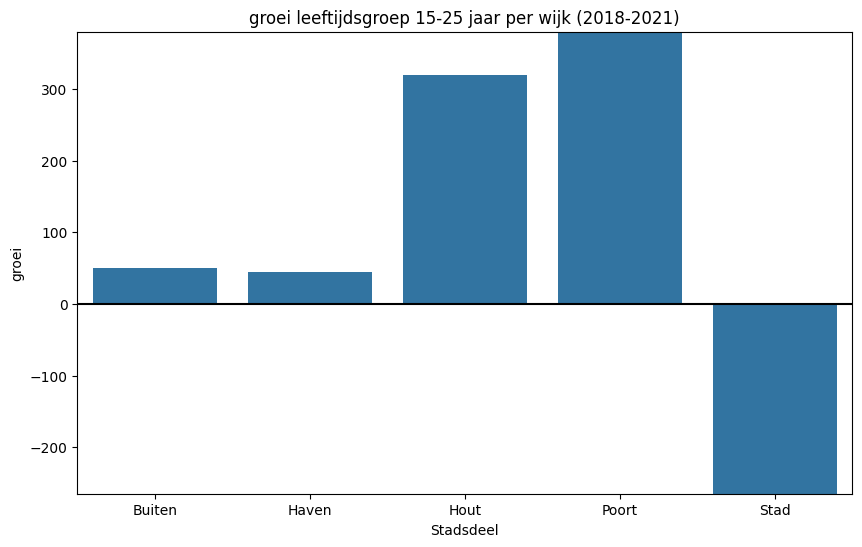

In [22]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=subset3.reset_index(),
    x='Stadsdeel',
    y='groei',
)

plt.title('groei leeftijdsgroep 15-25 jaar per wijk (2018-2021)')

ax.axhline(0, color='black')
ax.set_ylim(subset3['groei'].min(), subset3['groei'].max())
plt.show()

In [23]:
subset4 = df_groei

subset4['Peildatum'] = pd.to_datetime(subset4['Peildatum'])

subset4 = subset4[subset4['Jaar'].isin([2018, 2021])]

subset4 = subset4.pivot(index='Stadsdeel', columns='Jaar', values='AantalInwoners_5')

subset4["groei"] = subset4[2021] - subset4[2018]

subset4["percentage_groei"] = (subset4["groei"] / subset4[2018]) * 100

Dit onderdeel laat per stadsdeel zien hoe de leeftijdsgroepen en de totale bevolking zich tussen 2018 en 2021 hebben ontwikkeld.

## 3.6 Correlatiematrix en multicollineariteit analyseren (Mohammed)

In deze stap wordt onderzocht hoe de verschillende numerieke variabelen met elkaar samenhangen. Dit helpt bij het herkennen van mogelijke multicollineariteit, waarbij meerdere variabelen vrijwel dezelfde informatie bevatten.

In [24]:
df = pd.read_csv("../../data/processed/df_v10_ratio_temp.csv")

df.head()

,Peildatum,Wijk,AantalInwoners_5,k_0Tot15Jaar_8,k_15Tot25Jaar_9,Jaar,pct_0_15,pct_15_25,Ratio_0_15,Ratio_15_25
0,2018-01-01,WK003401,22790,3975,2420,2018,17.441860,10.618692,0.174419,0.106187
1,2019-01-01,WK003401,22875,3945,2415,2019,17.245902,10.557377,0.172459,0.105574
2,2020-01-01,WK003401,23275,4005,2485,2020,17.207304,10.676692,0.172073,0.106767
3,2021-01-01,WK003401,23530,4180,2465,2021,17.764556,10.475988,0.177646,0.104760
4,2018-01-01,WK003402,108800,19915,14890,2018,18.304228,13.685662,0.183042,0.136857


In [25]:
numeric_df = df.select_dtypes(include=["number"])
corr_matrix = numeric_df.corr()

corr_matrix

,AantalInwoners_5,k_0Tot15Jaar_8,k_15Tot25Jaar_9,Jaar,pct_0_15,pct_15_25,Ratio_0_15,Ratio_15_25
AantalInwoners_5,1.000000,0.996688,0.998529,0.021245,-0.503183,0.867106,-0.503183,0.867106
k_0Tot15Jaar_8,0.996688,1.000000,0.995371,0.009155,-0.447969,0.868357,-0.447969,0.868357
k_15Tot25Jaar_9,0.998529,0.995371,1.000000,0.007600,-0.511022,0.879091,-0.511022,0.879091
Jaar,0.021245,0.009155,0.007600,1.000000,0.096953,-0.042248,0.096953,-0.042248
pct_0_15,-0.503183,-0.447969,-0.511022,0.096953,1.000000,-0.625288,1.000000,-0.625288
pct_15_25,0.867106,0.868357,0.879091,-0.042248,-0.625288,1.000000,-0.625288,1.000000
Ratio_0_15,-0.503183,-0.447969,-0.511022,0.096953,1.000000,-0.625288,1.000000,-0.625288
Ratio_15_25,0.867106,0.868357,0.879091,-0.042248,-0.625288,1.000000,-0.625288,1.000000


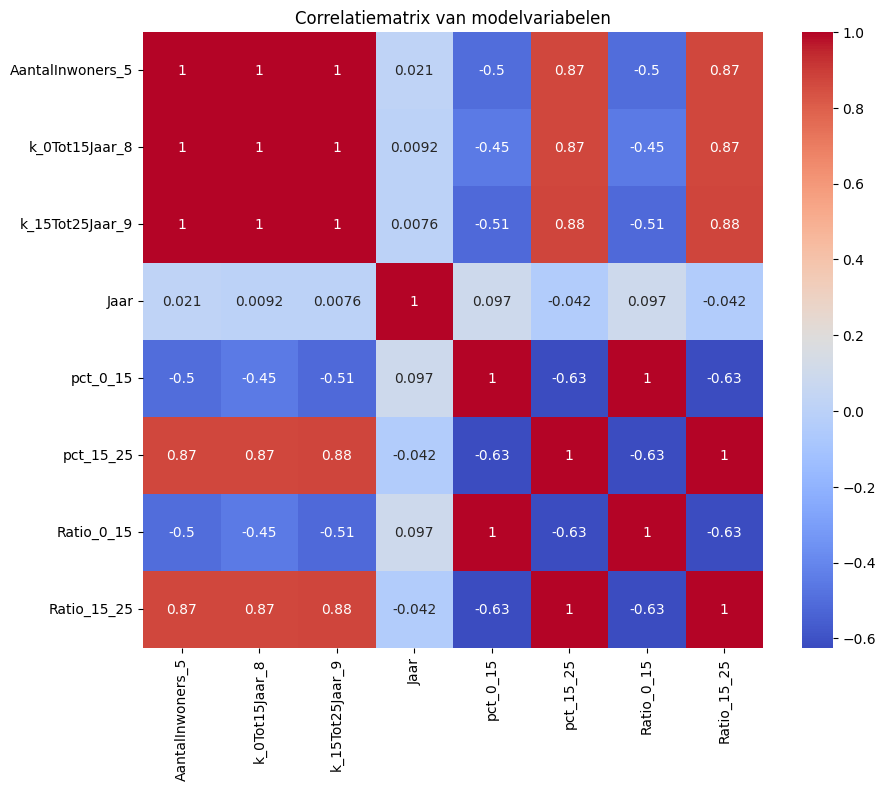

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")

plt.title("Correlatiematrix van modelvariabelen")
plt.show()

De correlatiematrix laat zien welke variabelen sterk samenhangen. Dit is belangrijk om te beoordelen welke variabelen later geschikt zijn voor gebruik in het model.

## 3.7 Noah – aanvulling volgt

Dit onderdeel blijft open, zodat Noah zijn bijdrage aan fase 3 later kan toevoegen.

## 3.8 Features samenvoegen tot één modeldataset (Faysal)

In deze stap worden de beschikbare feature-datasets samengevoegd tot één modelklare dataset. De merge gebeurt op de sleutel `Wijk` en `Jaar`.

In [27]:
import pandas as pd
from pathlib import Path

base_path = Path("../../data/processed/df_v8_ready_for_analysis.csv")
df_base = pd.read_csv(base_path)

df_base.head()

,Peildatum,Wijk,AantalInwoners_5,k_0Tot15Jaar_8,k_15Tot25Jaar_9,Jaar,pct_0_15,pct_15_25
0,2018-01-01,WK003401,22790,3975,2420,2018,17.441860,10.618692
1,2019-01-01,WK003401,22875,3945,2415,2019,17.245902,10.557377
2,2020-01-01,WK003401,23275,4005,2485,2020,17.207304,10.676692
3,2021-01-01,WK003401,23530,4180,2465,2021,17.764556,10.475988
4,2022-01-01,WK003401,1635,175,150,2022,10.703364,9.174312


In [28]:
df_base[["Wijk","Jaar"]].head()

df_base.duplicated(subset=["Wijk","Jaar"]).sum()

np.int64(0)

In [29]:
ratio_path = Path("../../data/processed/df_v10_ratio_temp.csv")

df_ratio = pd.read_csv(ratio_path)

df_ratio.head()

,Peildatum,Wijk,AantalInwoners_5,k_0Tot15Jaar_8,k_15Tot25Jaar_9,Jaar,pct_0_15,pct_15_25,Ratio_0_15,Ratio_15_25
0,2018-01-01,WK003401,22790,3975,2420,2018,17.441860,10.618692,0.174419,0.106187
1,2019-01-01,WK003401,22875,3945,2415,2019,17.245902,10.557377,0.172459,0.105574
2,2020-01-01,WK003401,23275,4005,2485,2020,17.207304,10.676692,0.172073,0.106767
3,2021-01-01,WK003401,23530,4180,2465,2021,17.764556,10.475988,0.177646,0.104760
4,2018-01-01,WK003402,108800,19915,14890,2018,18.304228,13.685662,0.183042,0.136857


In [30]:
df_ratio = df_ratio[[
    "Wijk",
    "Jaar",
    "Ratio_0_15",
    "Ratio_15_25"
]]

df_ratio.head()

,Wijk,Jaar,Ratio_0_15,Ratio_15_25
0,WK003401,2018,0.174419,0.106187
1,WK003401,2019,0.172459,0.105574
2,WK003401,2020,0.172073,0.106767
3,WK003401,2021,0.177646,0.104760
4,WK003402,2018,0.183042,0.136857


In [31]:
df_base["Wijk"] = df_base["Wijk"].astype(str).str.strip()
df_ratio["Wijk"] = df_ratio["Wijk"].astype(str).str.strip()

df_base["Jaar"] = df_base["Jaar"].astype(int)
df_ratio["Jaar"] = df_ratio["Jaar"].astype(int)
df_merged = df_base.merge(
    df_ratio,
    on=["Wijk","Jaar"],
    how="left"
)

df_merged.head()

,Peildatum,Wijk,AantalInwoners_5,k_0Tot15Jaar_8,k_15Tot25Jaar_9,Jaar,pct_0_15,pct_15_25,Ratio_0_15,Ratio_15_25
0,2018-01-01,WK003401,22790,3975,2420,2018,17.441860,10.618692,0.174419,0.106187
1,2019-01-01,WK003401,22875,3945,2415,2019,17.245902,10.557377,0.172459,0.105574
2,2020-01-01,WK003401,23275,4005,2485,2020,17.207304,10.676692,0.172073,0.106767
3,2021-01-01,WK003401,23530,4180,2465,2021,17.764556,10.475988,0.177646,0.104760
4,2022-01-01,WK003401,1635,175,150,2022,10.703364,9.174312,NaN,NaN


In [32]:
print("Rows base:", len(df_base))
print("Rows merged:", len(df_merged))

df_merged.isnull().sum()

Rows base: 237
Rows merged: 237


Peildatum             0
Wijk                  0
AantalInwoners_5      0
k_0Tot15Jaar_8        0
k_15Tot25Jaar_9       0
Jaar                  0
pct_0_15              0
pct_15_25             0
Ratio_0_15          217
Ratio_15_25         217
dtype: int64

In [33]:
df_base.dtypes
df_ratio.dtypes

Wijk               str
Jaar             int64
Ratio_0_15     float64
Ratio_15_25    float64
dtype: object

In [34]:
df_ratio = df_ratio[df_ratio["Jaar"].isin(df_base["Jaar"].unique())].copy()

print("Jaren base:", sorted(df_base["Jaar"].unique()))
print("Jaren ratio (na filter):", sorted(df_ratio["Jaar"].unique()))

Jaren base: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Jaren ratio (na filter): [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021)]


In [35]:
model_cols = [
    "Wijk",
    "Jaar",
    "AantalInwoners_5",
    "k_0Tot15Jaar_8",
    "k_15Tot25Jaar_9",
    "Ratio_0_15",
    "Ratio_15_25"
]

df_model = df_merged[model_cols].copy()

df_model.head()

,Wijk,Jaar,AantalInwoners_5,k_0Tot15Jaar_8,k_15Tot25Jaar_9,Ratio_0_15,Ratio_15_25
0,WK003401,2018,22790,3975,2420,0.174419,0.106187
1,WK003401,2019,22875,3945,2415,0.172459,0.105574
2,WK003401,2020,23275,4005,2485,0.172073,0.106767
3,WK003401,2021,23530,4180,2465,0.177646,0.104760
4,WK003401,2022,1635,175,150,NaN,NaN


In [36]:
matches = df_merged[["Ratio_0_15", "Ratio_15_25"]].notna().all(axis=1).sum()
totaal = len(df_merged)

print("Aantal rijen met ratio's gevuld:", matches, "van", totaal)
print("Aantal rijen zonder ratio's:", totaal - matches)

Aantal rijen met ratio's gevuld: 20 van 237
Aantal rijen zonder ratio's: 217


In [37]:
df_model.dtypes

Wijk                    str
Jaar                  int64
AantalInwoners_5      int64
k_0Tot15Jaar_8        int64
k_15Tot25Jaar_9       int64
Ratio_0_15          float64
Ratio_15_25         float64
dtype: object

In [38]:
output_path = Path("../../data/processed/df_v12_model_ready.csv")

df_model.to_csv(output_path, index=False)

output_path

WindowsPath('../../data/processed/df_v12_model_ready.csv')

In [39]:
df_model.groupby("Wijk")["Jaar"].min(), df_model.groupby("Wijk")["Jaar"].max()

(Wijk
 WK003401    2018
 WK003402    2018
 WK003403    2018
 WK003404    2018
 WK003405    2018
 WK003406    2022
 WK003407    2022
 WK003408    2022
 WK003409    2022
 WK003410    2022
 WK003411    2022
 WK003414    2022
 WK003417    2022
 WK003418    2022
 WK003419    2022
 WK003420    2022
 WK003421    2022
 WK003422    2022
 WK003423    2022
 WK003424    2022
 WK003425    2022
 WK003426    2022
 WK003427    2022
 WK003428    2022
 WK003429    2022
 WK003430    2022
 WK003431    2022
 WK003432    2024
 WK003435    2023
 WK003437    2022
 WK003441    2022
 WK003442    2022
 WK003443    2022
 WK003444    2022
 WK003445    2022
 WK003446    2022
 WK003447    2022
 WK003448    2022
 WK003449    2022
 WK003450    2022
 WK003451    2022
 WK003452    2022
 WK003453    2022
 WK003456    2022
 WK003458    2022
 WK003459    2025
 WK003460    2022
 WK003461    2022
 WK003462    2022
 WK003463    2022
 WK003465    2022
 WK003466    2022
 WK003475    2022
 WK003476    2022
 WK003477    2022
 WK0

In [40]:
df_ratio["Jaar"].unique()
df_base["Jaar"].unique()

array([2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025])

Na het samenvoegen wordt gecontroleerd of het aantal rijen gelijk blijft, hoeveel matches daadwerkelijk zijn gevonden en of de modelvariabelen het juiste datatype hebben. De uiteindelijke dataset wordt opgeslagen als `df_v12_model_ready.csv`.

## Modeling
We gebruiken lineaire regressie als baseline model.

## Evaluatie

## Visualisatie Resultaten

## Conclusie
- Hoe goed presteert het model?
- Is het bruikbaar voor de gemeente?
- Wat zijn beperkingen?
- Aanbevelingen voor vervolgonderzoek.